|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 4:</h2>|<h1>The Scheduler<h1>|
|<h2>Section:</h2>|<h1>Admission and preemption<h1>|
|<h2>Lecture:</h2>|<h1><b>Swap or throw it away: the inequality, and why it is not the decision<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Swap, or throw it away?

You have decided to preempt a sequence. Its K and V are sitting in blocks
you need. Two options:

- **swap**: copy the blocks to CPU memory, and copy them back later
- **recompute**: free the blocks, and prefill the sequence again when it
  resumes

The usual advice is that recompute wins. Measure it rather than believing it.

In [2]:
# how fast is the road to CPU memory?
n = 256*1024*1024 // 2
g = torch.empty(n, dtype=torch.bfloat16, device='cuda')
c = torch.empty(n, dtype=torch.bfloat16, pin_memory=True)

out_ms = cudalib.bench_ms(lambda: c.copy_(g), iters=10, warmup=3, best_of=2)
in_ms  = cudalib.bench_ms(lambda: g.copy_(c), iters=10, warmup=3, best_of=2)
pcie   = (n*2)/(out_ms*1e-3)/1e9
hbm    = cudalib.peak_bandwidth(fresh=True)

print(f'GPU -> CPU: {pcie:5.1f} GB/s')
print(f'CPU -> GPU: {(n*2)/(in_ms*1e-3)/1e9:5.1f} GB/s')
print(f'HBM:        {hbm:5.0f} GB/s   ({hbm/pcie:.0f}x faster than the road out)')

del g, c
torch.cuda.empty_cache()

GPU -> CPU:  11.7 GB/s
CPU -> GPU:  12.4 GB/s
HBM:          296 GB/s   (25x faster than the road out)


### And how fast is prefill?

In [3]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()
KV_PER_TOKEN = 112 * 1024      # measured in Part 1

@torch.inference_mode()
def prefill_ms(L):
  x = torch.randint(0, 1000, (1,L), device='cuda')
  return cudalib.bench_ms(lambda: model(x, use_cache=True, logits_to_keep=1),
                          iters=8, warmup=3, best_of=2)

Ls = [256, 512, 1024, 2048]
print(f"{'tokens':>7} {'recompute':>11} {'swap out+in':>13} {'winner':>11}")
rows = []
for L in Ls:
  rec  = prefill_ms(L)
  swap = 2 * (L*KV_PER_TOKEN) / (pcie*1e9) * 1000
  rows.append((L, rec, swap))
  print(f'{L:>7} {rec:>10.1f}ms {swap:>12.1f}ms {("swap" if swap<rec else "recompute"):>11}')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 10020.81it/s]

 tokens   recompute   swap out+in      winner


    256       13.5ms          5.0ms        swap


    512       18.9ms         10.0ms        swap


   1024       36.5ms         20.1ms        swap


   2048       75.1ms         40.2ms        swap


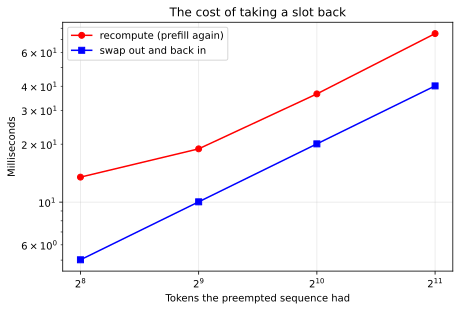

In [4]:
r = np.array(rows)
plt.figure(figsize=(7,4.5))
plt.plot(r[:,0], r[:,1], 'ro-', label='recompute (prefill again)')
plt.plot(r[:,0], r[:,2], 'bs-', label='swap out and back in')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Tokens the preempted sequence had'); plt.ylabel('Milliseconds')
plt.title('The cost of taking a slot back')
plt.legend(); plt.grid(alpha=.3); plt.show()

### On this machine, swapping wins. So why does vLLM prefer recompute?

Both lines are straight and parallel, because both costs are linear in the
number of tokens. Which one is lower is decided by a single inequality:

$$\text{recompute wins when}\quad
  \frac{\text{prefill ms}}{\text{token}} < \frac{2 \times \text{KV bytes/token}}{\text{PCIe}}$$

Plug your own model in, because both sides move:

In [5]:
per_token_prefill = (rows[-1][1] - rows[0][1]) / (Ls[-1] - Ls[0])
per_token_swap    = 2 * KV_PER_TOKEN / (pcie*1e9) * 1000

print(f'this model: prefill {per_token_prefill:.4f} ms/token, swap {per_token_swap:.4f} ms/token')
print(f'-> {"recompute" if per_token_prefill < per_token_swap else "swap"} wins here, by {max(per_token_prefill,per_token_swap)/min(per_token_prefill,per_token_swap):.1f}x\n')

# a 7B model: 32 layers, 8 kv heads, 128 head_dim, bf16
kv_7b   = 2*32*8*128*2
flops_7b = 2*7e9                      # per token of prefill
sustained = 50e12                     # TFLOP/s, from Part 1
print(f'a 7B model: prefill {1000*flops_7b/sustained:.4f} ms/token, '
      f'swap {1000*2*kv_7b/(pcie*1e9):.4f} ms/token')

this model: prefill 0.0344 ms/token, swap 0.0196 ms/token
-> swap wins here, by 1.8x

a 7B model: prefill 0.2800 ms/token, swap 0.0224 ms/token


A bigger model makes recompute **more** expensive per token, not less, and
GQA has already made its KV cache small. So the arithmetic alone points at
swapping for most models on most machines.

The reasons real engines still default to recompute are not in this
inequality:

- **Swapping in is on the critical path.** The sequence cannot run until its
  bytes are back. A recompute can be cut into chunks and co-scheduled with
  other work, which is exactly what stage 11 builds.
- **PCIe is shared.** This measurement had the bus to itself. A real node is
  moving weights, activations and other tenants' data across it.
- **The prefix may still be cached.** Stage 09 means a recompute often does
  not start from zero.
- **Swapping needs pinned host memory reserved up front**, which is memory you
  could have given to the KV pool instead.

So the honest statement is not "recompute is faster". It is that recompute is
**schedulable**, and swapping is not.

    ./vc guide 10